# Dust absorption and emission

Dust absorbs the ultraviolet and optical light of a galaxy — from its stars, from the gas they ionize, and from an
active nucleus — and re-radiates that energy in the infrared. This notebook analyzes a Galacticus model which follows
both sides of that exchange.

The model is `parameters/tutorials/dustEmission.xml`. It builds a single merger tree for a halo of
$10^{12}\,M_\odot$, forming a galaxy with a supermassive black hole, and outputs it at redshift one — an epoch when
it is actively forming stars — with:

* spectra of the disk stars, the spheroid stars, and the AGN, and luminosities of emission lines from HII regions and
  from the narrow-line region of the AGN;
* for each of these, attenuated by the dust model of Charlot & Fall (2000), the light transmitted, and the light
  absorbed by each *phase* of dust: **birth clouds**, which surround stars younger than 10 Myr, and the **diffuse
  interstellar medium** (a screen whose optical depth scales with the surface density of metals in the gas);
* the spectrum of thermal emission from the dust. The light absorbed by birth clouds is re-emitted by warm dust at a
  fixed 50 K. The light absorbed by the diffuse medium heats PAHs — emitting in the single-photon approximation of
  Richie & Hensley (2026), with a spectrum set by the *shape* of the light they absorb — and larger grains, whose
  temperature follows from energy balance.

Run the model from the root of the Galacticus source tree before running this notebook:

```sh
./Galacticus.exe parameters/tutorials/dustEmission.xml
```

The output is read with [dendros](https://github.com/galacticusorg/dendros) (`pip install 'dendros[plot]'`).

In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
from dendros import open_outputs

# The model writes its output to the root of the Galacticus source tree. This notebook lives two levels below it
# (tutorials/models/); set GALACTICUS_EXEC_PATH to the root if you run it from elsewhere.
root       = os.environ.get('GALACTICUS_EXEC_PATH', os.path.abspath(os.path.join(os.getcwd(), os.pardir, os.pardir)))
outputFile = os.path.join(root, 'dustEmissionTutorial.hdf5')
if not os.path.exists(outputFile):
    raise FileNotFoundError(f"{outputFile} not found - run `./Galacticus.exe parameters/tutorials/dustEmission.xml` "
                            "from the root of the Galacticus source tree first")

# Physical constants, in the units Galacticus uses: wavelengths in Å, luminosities in L☉.
speedOfLight     = 2.99792458e18  # Å s⁻¹
luminositySolar  = 3.845e26       # W
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

## Opening the output

`open_outputs` returns a collection which can list the outputs of a run, list the properties written for each
galaxy, and read them. There is a single output, at redshift one.

In [2]:
model = open_outputs(outputFile)
model.validate_completion()
print(model.list_outputs(format='tabulate'))

      index  name        time    scale_factor    redshift  output_type
--  -------  -------  -------  --------------  ----------  -------------
 0        1  Output1  5.98322             0.5           1  snapshot


In [3]:
nodeData = model['Outputs/Output1/nodeData']
names    = sorted(nodeData.keys())
print(f"{len(names)} datasets per galaxy, for example:")
for name in names:
    if name in ('massStellarTotal', 'massBlackHole', 'totalStarFormationRate') or name.endswith(':dustAttenuated:charlotFall2000'):
        print("  ", name)

106 datasets per galaxy, for example:
   agnSED:dustAttenuated:charlotFall2000
   diskStellarSED:inoue2014:dustAttenuated:charlotFall2000
   luminosityEmissionLineAGN:balmerAlpha6565:dustAttenuated:charlotFall2000
   luminosityEmissionLineAGN:balmerBeta4863:dustAttenuated:charlotFall2000
   luminosityEmissionLineAGN:nitrogenII6585:dustAttenuated:charlotFall2000
   luminosityEmissionLineAGN:oxygenII3727:dustAttenuated:charlotFall2000
   luminosityEmissionLineAGN:oxygenIII5008:dustAttenuated:charlotFall2000
   luminosityEmissionLineTotal:balmerAlpha6565:dustAttenuated:charlotFall2000
   luminosityEmissionLineTotal:balmerBeta4863:dustAttenuated:charlotFall2000
   luminosityEmissionLineTotal:nitrogenII6585:dustAttenuated:charlotFall2000
   luminosityEmissionLineTotal:oxygenII3727:dustAttenuated:charlotFall2000
   luminosityEmissionLineTotal:oxygenIII5008:dustAttenuated:charlotFall2000
   massBlackHole
   massStellarTotal
   spheroidStellarSED:inoue2014:dustAttenuated:charlotFall2000
   tot

The galaxies in the tree are all written; we analyze the one with the most stars — the central galaxy of the halo.

In [4]:
def read(name):
    # Read one dataset for every galaxy in the output.
    # Values are returned in Galacticus' own units (as_quantity=False skips conversion to astropy Quantities).
    return model.read('Output1', [f'nodeData/{name}'], as_quantity=False)[f'nodeData/{name}']

massStellar = read('massStellarTotal')
galaxy      = int(np.argmax(massStellar))
print(f"stellar mass           : {massStellar[galaxy]:.3e} M☉")
print(f"black hole mass        : {read('massBlackHole')[galaxy]:.3e} M☉")
print(f"star formation rate    : {read('totalStarFormationRate')[galaxy]:.3e} M☉/Gyr")

stellar mass           : 1.198e+10 M☉
black hole mass        : 1.163e+07 M☉
star formation rate    : 3.738e+08 M☉/Gyr


## Finding the spectra

Properties written by the dust attenuation extractor are named after the property they attenuate. For a source
named `X`, `X` is the intrinsic luminosity, `X:dustAttenuated:charlotFall2000` the luminosity transmitted through the
dust, and `X:dustAbsorbed:charlotFall2000:<phase>` the luminosity absorbed by each phase. Spectra are arrays of
$L_\nu$ (in $L_\odot\,\mathrm{Hz}^{-1}$) with one column per wavelength; the wavelengths are in a companion
`...ColumnValues` dataset, written once for each distinct grid.

In [5]:
attenuator = 'charlotFall2000'
phases     = sorted({name.split(':')[-1] for name in names if f':dustAbsorbed:{attenuator}:' in name and not name.endswith(('ColumnValues', 'Columns'))})
sources    = sorted({name.split(':dustAttenuated:')[0] for name in names if name.endswith(f':dustAttenuated:{attenuator}')})
spectra    = [source for source in sources if nodeData[source + f':dustAttenuated:{attenuator}'].ndim == 2]
lines      = [source for source in sources if nodeData[source + f':dustAttenuated:{attenuator}'].ndim == 1]
print("phases of dust :", phases)
print("spectra        :", spectra)
print("emission lines :", lines)

def wavelengths(name):
    # The wavelengths of a spectrum: its own column values, or those of another property of the same source, or of any
    # other property on a grid of the same length.
    count      = nodeData[name].shape[1]
    base       = name.split(':dust')[0]
    candidates = [name] + [other for other in names if other.split(':dust')[0] == base and not other.endswith(('ColumnValues', 'Columns'))]
    candidates = [candidate + 'ColumnValues' for candidate in candidates] + [other for other in names if other.endswith('ColumnValues')]
    for candidate in candidates:
        if candidate in nodeData and nodeData[candidate].shape[0] == count:
            return nodeData[candidate][:]
    raise KeyError(f"no wavelengths found for {name}")

def spectrum(name):
    return wavelengths(name), read(name)[galaxy]

def unitsInSI(name):
    # The factor converting a property to SI units, from the `unitsInSI` field of its `units` attribute.
    return nodeData[name].attrs['units']['unitsInSI']

def luminosityPerLogWavelength(wavelength, luminosityNu):
    # ν L_ν = λ L_λ, in L☉: the luminosity per unit ln λ.
    return speedOfLight / wavelength * luminosityNu

def positive(values):
    # Values for a logarithmic plot: zeros become gaps rather than vertical drops.
    return np.where(values > 0.0, values, np.nan)

def limitsLogarithmic(axes, curves, decades):
    # Set the vertical range of a logarithmic plot to span the given number of decades below the largest value plotted.
    peak = max(np.nanmax(curve) for curve in curves if np.any(np.isfinite(curve)))
    axes.set_ylim(peak / 10.0**decades, 2.0 * peak)

phases of dust : ['birthCloud', 'screenSurfaceDensityMetals']
spectra        : ['agnSED', 'diskStellarSED:inoue2014', 'spheroidStellarSED:inoue2014']
emission lines : ['luminosityEmissionLineAGN:balmerAlpha6565', 'luminosityEmissionLineAGN:balmerBeta4863', 'luminosityEmissionLineAGN:nitrogenII6585', 'luminosityEmissionLineAGN:oxygenII3727', 'luminosityEmissionLineAGN:oxygenIII5008', 'luminosityEmissionLineTotal:balmerAlpha6565', 'luminosityEmissionLineTotal:balmerBeta4863', 'luminosityEmissionLineTotal:nitrogenII6585', 'luminosityEmissionLineTotal:oxygenII3727', 'luminosityEmissionLineTotal:oxygenIII5008']


## Starlight and AGN light, before and after dust

Each source is shown intrinsic (dashed) and after passing through the dust (solid). Dust removes most of the
ultraviolet light, and reddens what remains. The AGN is seen through the dust of both the disk and the spheroid,
but not through birth clouds, which surround only young stars. The black hole in this galaxy accretes slowly, so its AGN
is faint — far below the starlight, and may fall below the plotted range; its light is treated in the same way as that
of a luminous AGN, which a more massive halo (try `massTree` of $10^{13}\,M_\odot$) is more likely to host.

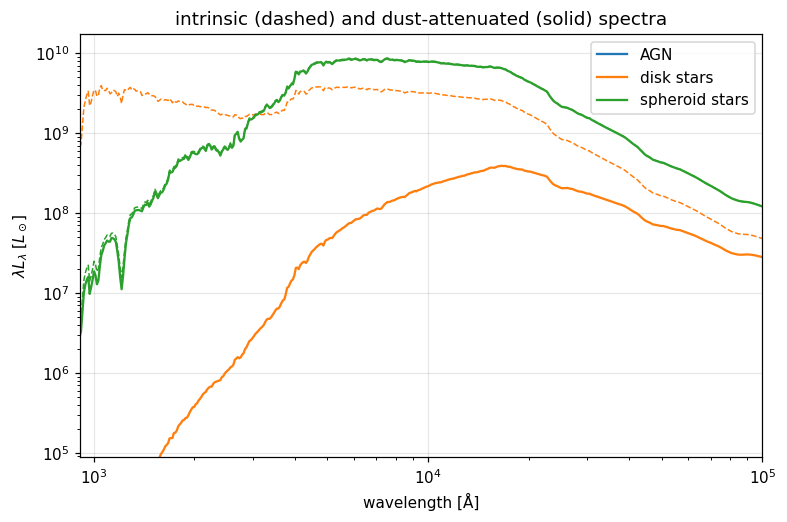

In [6]:
labels = {'diskStellarSED': 'disk stars', 'spheroidStellarSED': 'spheroid stars', 'agnSED': 'AGN'}
def label(source):
    for key, value in labels.items():
        if source.startswith(key):
            return value
    return source

figure, axes = plt.subplots(figsize=(8, 5))
curves = []
for source, color in zip(spectra, plt.rcParams['axes.prop_cycle'].by_key()['color']):
    wavelength, intrinsic = spectrum(source)
    _         , attenuated = spectrum(source + f':dustAttenuated:{attenuator}')
    inRange = (wavelength > 912.0) & (wavelength < 1.0e5)
    curves += [positive(luminosityPerLogWavelength(wavelength, intrinsic))[inRange]]
    axes.plot(wavelength, positive(luminosityPerLogWavelength(wavelength, intrinsic )), color=color, ls='--', lw=1)
    axes.plot(wavelength, positive(luminosityPerLogWavelength(wavelength, attenuated)), color=color, ls='-' , lw=1.5, label=label(source))
axes.set_xscale('log'); axes.set_yscale('log')
axes.set_xlim(912.0, 1.0e5)
limitsLogarithmic(axes, curves, 5)
axes.set_xlabel('wavelength [Å]'); axes.set_ylabel(r'$\lambda L_\lambda$ [$L_\odot$]')
axes.set_title('intrinsic (dashed) and dust-attenuated (solid) spectra')
axes.legend()
plt.show()

## Where the light is absorbed

The light absorbed by each phase of dust, summed over all sources. Birth clouds absorb the ultraviolet light of the
youngest stars — a large share of the energy despite surrounding only a small fraction of the stellar mass — while
the diffuse medium absorbs light from stars of all ages, and from the AGN.

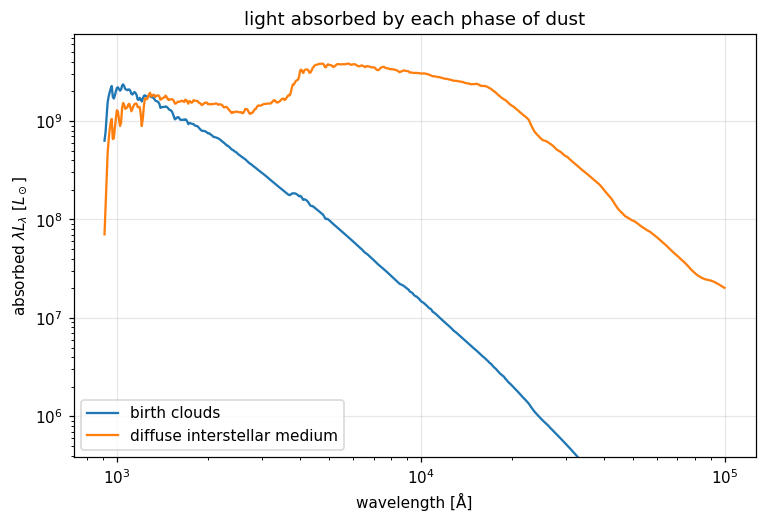

In [7]:
figure, axes = plt.subplots(figsize=(8, 5))
phaseLabels = {'birthCloud': 'birth clouds', 'screenSurfaceDensityMetals': 'diffuse interstellar medium'}
grid        = np.logspace(np.log10(912.0), 5.0, 600)
curves      = []
for phase in phases:
    total = np.zeros_like(grid)
    for source in spectra:
        wavelength, absorbed = spectrum(source + f':dustAbsorbed:{attenuator}:{phase}')
        total += np.interp(grid, wavelength, absorbed, left=0.0, right=0.0)
    curve = positive(luminosityPerLogWavelength(grid, total))
    if np.any(np.isfinite(curve)):
        curves.append(curve)
        axes.plot(grid, curve, label=phaseLabels.get(phase, phase))
    else:
        print(f"the {phaseLabels.get(phase, phase)} absorb no continuum light in this galaxy")
axes.set_xscale('log'); axes.set_yscale('log')
limitsLogarithmic(axes, curves, 4)
axes.set_xlabel('wavelength [Å]'); axes.set_ylabel(r'absorbed $\lambda L_\lambda$ [$L_\odot$]')
axes.set_title('light absorbed by each phase of dust')
axes.legend()
plt.show()

## Re-emission in the infrared

The dust emission spectrum, `dustEmissionSED:charlotFall2000`, and the emission of each phase. Warm dust in birth
clouds peaks near 60 µm. In the diffuse medium, PAHs produce the emission bands between 3 and 20 µm, and larger grains
the far-infrared peak.

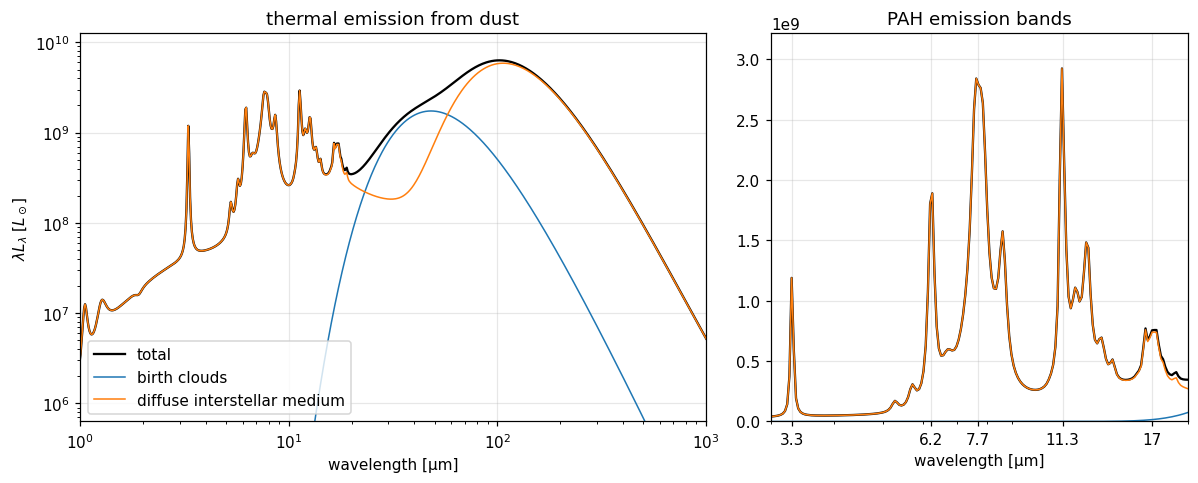

In [8]:
emission = f'dustEmissionSED:{attenuator}'
figure, (axes, zoom) = plt.subplots(1, 2, figsize=(11, 4.5), gridspec_kw={'width_ratios': [3, 2]})
wavelength, total = spectrum(emission)
for target in (axes, zoom):
    target.plot(wavelength / 1.0e4, positive(luminosityPerLogWavelength(wavelength, total)), color='k', lw=1.5, label='total')
    for phase in phases:
        _, perPhase = spectrum(f'{emission}:{phase}')
        target.plot(wavelength / 1.0e4, positive(luminosityPerLogWavelength(wavelength, perPhase)), lw=1, label=phaseLabels.get(phase, phase))
axes.set_xscale('log'); axes.set_yscale('log')
axes.set_xlim(1.0, 1.0e3)
limitsLogarithmic(axes, [luminosityPerLogWavelength(wavelength, total)], 4)
axes.set_xlabel('wavelength [µm]'); axes.set_ylabel(r'$\lambda L_\lambda$ [$L_\odot$]')
axes.set_title('thermal emission from dust')
axes.legend()
from matplotlib.ticker import FixedLocator, FixedFormatter, NullFormatter
zoom.set_xscale('log'); zoom.set_xlim(3.0, 20.0)
inBand = (wavelength > 3.0e4) & (wavelength < 2.0e5)
zoom.set_ylim(0.0, 1.1 * luminosityPerLogWavelength(wavelength, total)[inBand].max())
zoom.xaxis.set_major_locator(FixedLocator([3.3, 6.2, 7.7, 11.3, 17.0]))
zoom.xaxis.set_major_formatter(FixedFormatter(['3.3', '6.2', '7.7', '11.3', '17']))
zoom.xaxis.set_minor_formatter(NullFormatter())
zoom.set_xlabel('wavelength [µm]')
zoom.set_title('PAH emission bands')
plt.tight_layout()
plt.show()

## The panchromatic spectrum

Putting the two halves together: the light which escapes the dust, and the light the dust emits, compared with the
intrinsic light of the galaxy.

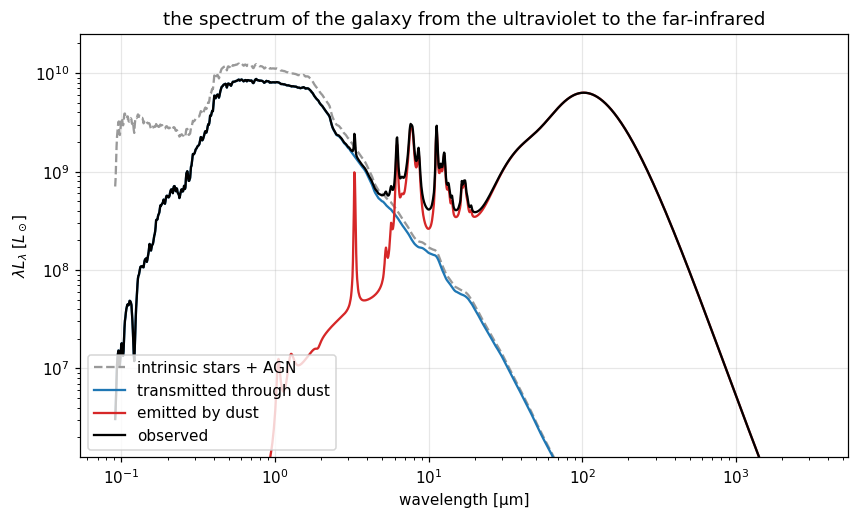

In [9]:
grid = np.logspace(np.log10(912.0), 7.5, 1500)
def onGrid(name):
    wavelength, values = spectrum(name)
    return np.interp(grid, wavelength, values, left=0.0, right=0.0)
intrinsic   = sum(onGrid(source                                     ) for source in spectra)
transmitted = sum(onGrid(source + f':dustAttenuated:{attenuator}'   ) for source in spectra)
dust        = onGrid(emission)
figure, axes = plt.subplots(figsize=(9, 5))
observed = transmitted + dust
axes.plot(grid / 1.0e4, positive(luminosityPerLogWavelength(grid, intrinsic  )), color='0.6', ls='--', label='intrinsic stars + AGN')
axes.plot(grid / 1.0e4, positive(luminosityPerLogWavelength(grid, transmitted)), color='C0' , label='transmitted through dust')
axes.plot(grid / 1.0e4, positive(luminosityPerLogWavelength(grid, dust       )), color='C3' , label='emitted by dust')
axes.plot(grid / 1.0e4, positive(luminosityPerLogWavelength(grid, observed   )), color='k'  , lw=1.5, label='observed')
axes.set_xscale('log'); axes.set_yscale('log')
limitsLogarithmic(axes, [positive(luminosityPerLogWavelength(grid, intrinsic)), positive(luminosityPerLogWavelength(grid, observed))], 4)
axes.set_xlabel('wavelength [µm]'); axes.set_ylabel(r'$\lambda L_\lambda$ [$L_\odot$]')
axes.set_title('the spectrum of the galaxy from the ultraviolet to the far-infrared')
axes.legend()
plt.show()

## Energy balance

The dust must emit exactly the energy it absorbs. The absorbed luminosity is integrated over frequency for each
spectrum, and summed with the absorbed luminosity of the emission lines (converted to $L_\odot$ using their units).
The emitted luminosity is integrated over the resolution elements of the dust emission spectrum. Adjacent elements are
spaced by a factor $f^2$ in wavelength, and each spans $\lambda/f$ to $\lambda f$, so its width in frequency is
$\nu (f - 1/f)$.

In [10]:
absorbed = {}
for phase in phases:
    total = 0.0
    for source in spectra:
        wavelength, values = spectrum(source + f':dustAbsorbed:{attenuator}:{phase}')
        frequency = speedOfLight / wavelength
        total    += np.sum(0.5 * (values[1:] + values[:-1]) * np.abs(frequency[:-1] - frequency[1:]))
    for source in lines:
        name   = source + f':dustAbsorbed:{attenuator}:{phase}'
        total += read(name)[galaxy] * unitsInSI(name) / luminositySolar
    absorbed[phase] = total

wavelength, _ = spectrum(emission)
factor        = np.sqrt(wavelength[1] / wavelength[0])  # the factor f, from the spacing of the wavelength grid
for phase in phases:
    wavelength, values = spectrum(f'{emission}:{phase}')
    emitted = np.sum(values * speedOfLight / wavelength * (factor - 1.0 / factor))
    print(f"{phaseLabels.get(phase, phase):28s}: absorbed {absorbed[phase]:.4e} L☉, emitted {emitted:.4e} L☉, ratio {emitted / absorbed[phase]:.5f}")

birth clouds                : absorbed 1.8294e+09 L☉, emitted 1.8294e+09 L☉, ratio 1.00001
diffuse interstellar medium : absorbed 7.5659e+09 L☉, emitted 7.5671e+09 L☉, ratio 1.00017


## Emission lines

Dust also attenuates emission lines. The ratio of H$\alpha$ to H$\beta$ — the Balmer decrement — is about 2.86 for
unattenuated gas, and grows as dust preferentially removes the bluer H$\beta$. Lines from HII regions pass through
birth clouds as well as the diffuse medium, so are more heavily attenuated than the continuum of the stars which power
them; lines from the AGN pass only through the diffuse medium.

In [11]:
def lineLuminosity(source, suffix=''):
    name = source + suffix
    return read(name)[galaxy] * unitsInSI(name) / luminositySolar

groups = {}
for source in lines:
    match = re.match(r'(.*):(balmerAlpha6565|balmerBeta4863|oxygenII3727|oxygenIII5008|nitrogenII6585)$', source)
    if match:
        groups.setdefault(match.group(1), {})[match.group(2)] = source
for group, members in groups.items():
    if not {'balmerAlpha6565', 'balmerBeta4863'} <= set(members):
        continue
    kind = 'AGN narrow-line region' if 'AGN' in group else 'HII regions'
    hydrogenAlpha, hydrogenBeta = members['balmerAlpha6565'], members['balmerBeta4863']
    ratioIntrinsic  = lineLuminosity(hydrogenAlpha) / lineLuminosity(hydrogenBeta) if hydrogenAlpha in nodeData else float('nan')
    ratioAttenuated = lineLuminosity(hydrogenAlpha, f':dustAttenuated:{attenuator}') / lineLuminosity(hydrogenBeta, f':dustAttenuated:{attenuator}')
    print(f"{kind:24s}: Hα/Hβ intrinsic {ratioIntrinsic:.2f}, attenuated {ratioAttenuated:.2f}")
    for line, source in sorted(members.items()):
        transmitted = lineLuminosity(source, f':dustAttenuated:{attenuator}')
        intrinsic   = lineLuminosity(source) if source in nodeData else float('nan')
        print(f"    {line:16s}: {intrinsic:.3e} L☉ intrinsic, {transmitted:.3e} L☉ transmitted ({transmitted / intrinsic:.1%})")

AGN narrow-line region  : Hα/Hβ intrinsic 2.77, attenuated 6.45
    balmerAlpha6565 : 3.492e+01 L☉ intrinsic, 9.429e-01 L☉ transmitted (2.7%)
    balmerBeta4863  : 1.260e+01 L☉ intrinsic, 1.463e-01 L☉ transmitted (1.2%)
    nitrogenII6585  : 4.840e+00 L☉ intrinsic, 1.317e-01 L☉ transmitted (2.7%)
    oxygenII3727    : 1.608e+01 L☉ intrinsic, 7.497e-02 L☉ transmitted (0.5%)
    oxygenIII5008   : 1.844e+02 L☉ intrinsic, 2.345e+00 L☉ transmitted (1.3%)
HII regions             : Hα/Hβ intrinsic 2.81, attenuated 7.78
    balmerAlpha6565 : 1.426e+07 L☉ intrinsic, 1.822e+05 L☉ transmitted (1.3%)
    balmerBeta4863  : 5.078e+06 L☉ intrinsic, 2.342e+04 L☉ transmitted (0.5%)
    nitrogenII6585  : 1.824e+06 L☉ intrinsic, 2.347e+04 L☉ transmitted (1.3%)
    oxygenII3727    : 2.907e+06 L☉ intrinsic, 4.463e+03 L☉ transmitted (0.2%)
    oxygenIII5008   : 1.989e+07 L☉ intrinsic, 1.025e+05 L☉ transmitted (0.5%)


## Going further

* Change the dust model: `dustAttenuation` accepts other attenuators — `screenSurfaceDensityMetals` alone, or the
  radiative transfer atlases `atlasFerrara2000` and `atlasCompendium` (for which the spectra of stars, but not of
  the AGN, can be attenuated).
* Change the emission: replace `blackBodyModified` by the templates of Dale & Helou (2002) (`daleHelou2002`) or the
  models of Draine & Li (2007) (`draineLi2007`), or vary the PAH size distribution and ionization
  (`sizeDistribution`, `ionizationFunction`) of `richieHensley2026`.
* Run the model at higher redshift, or for a suite of trees, and compare the infrared luminosity with the star
  formation rate.